#### This data set consists of positions and absorbed power outputs of wave energy converters (WECs) in four real wave scenarios from the southern coast of Australia.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor

## Data Cleaning and Preparations

In [2]:
df = pd.read_csv('Perth_Data.csv')
labels = [f"X{i+1}" for i in range(16)] + [f"Y{i+1}" for i in range(16)]  + [f"P{i+1}" for i in range(16)] + ["Total Power"]
df.columns = labels
df.dropna()
before = len(df)
df = df.dropna()
after = len(df)
print(f"{before} rows before removal, {after} rows after removal due to NaN values")

71999 rows before removal, 71999 rows after removal due to NaN values


There is no mising values in dataset

X1-X16 - the posision X of Converter

Y1-Y16 - the position Y of Converter

P1-P16 - Power absorbed

Total power - output of the farm: Powerall

In [3]:
df.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,P8,P9,P10,P11,P12,P13,P14,P15,P16,Total Power
0,427.4820,147.4593,474.9960,9.5407,258.2593,404.2589,524.3422,44.4009,70.4385,468.8828,...,98879.6861,82893.9171,89158.6518,80356.5067,100927.1007,89760.5631,97828.2206,99214.7876,79108.3094,1479133.940
1,423.7709,155.9451,470.8182,4.0438,253.8868,390.2231,509.0224,50.7996,72.8076,463.4203,...,100504.0370,81572.7820,89932.3496,80588.3130,100977.1693,90274.1347,97757.2251,99333.6857,79691.2458,1475814.243
2,431.8288,146.6720,466.1145,7.0164,261.3787,408.9941,521.9852,44.0360,77.5854,450.5736,...,99857.6062,82267.0302,88657.7954,79139.2437,100480.0554,91102.1702,98224.0435,100672.3076,78387.9296,1484052.684
3,437.7897,141.3579,474.3819,4.3434,256.5644,393.0113,516.1617,52.4880,66.1179,457.0365,...,99953.9882,80579.2854,88819.3409,80145.6969,100693.3759,89663.6079,97947.9575,100924.1871,80104.7240,1479350.362
4,450.8980,144.7559,475.3267,2.5512,241.1346,400.2228,510.2312,54.6467,78.7078,466.5793,...,101316.4648,77925.4484,87779.9566,81388.1816,100582.6873,91470.9832,97741.0470,100097.4638,79993.7164,1480235.758


In [4]:
df.describe()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,P8,P9,P10,P11,P12,P13,P14,P15,P16,Total Power
count,71999.000000,71999.000000,71999.000000,71999.000000,71999.000000,71999.000000,71999.000000,71999.000000,71999.000000,71999.000000,...,71999.000000,71999.000000,71999.000000,71999.000000,71999.000000,71999.000000,71999.000000,71999.000000,71999.000000,7.199900e+04
mean,307.699347,263.070612,310.030123,280.013796,271.573227,271.823645,271.624806,265.369786,300.027841,265.177959,...,87172.608685,87227.504851,87479.666124,87259.717304,86416.344782,86879.880051,86110.006386,88026.099911,87450.222314,1.394474e+06
std,186.407136,182.581205,188.617119,180.756415,183.358872,181.908406,180.590296,182.812626,179.270315,183.327602,...,10574.714409,10196.668231,10087.897047,10470.723965,10574.225552,9942.141893,10371.876481,10471.574508,10477.575900,5.224964e+04
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,46239.804500,50114.929100,47183.047800,49291.778000,49549.990600,49465.685600,47027.625800,48982.438200,46881.573700,1.177711e+06
25%,132.551750,97.074000,126.133550,117.152850,98.514700,102.462550,105.551400,94.713600,134.877500,101.783700,...,79380.334100,79774.810650,79824.903400,79398.645350,78207.234750,80018.621350,78324.298250,80115.162800,79372.887300,1.359069e+06
50%,343.866000,243.848700,347.420000,282.059100,265.251300,267.371400,261.311300,251.314100,316.861100,253.391800,...,88612.820700,88460.903900,88767.991600,88451.697000,87220.716100,87720.523300,86479.413300,90513.480700,89574.098300,1.388877e+06
75%,477.287200,427.381950,480.394400,440.355200,441.643150,435.246350,436.595450,441.454600,461.048700,435.321450,...,96919.687700,96704.534750,96880.955100,96922.406900,96700.561650,96550.212600,96575.218750,97074.449000,96752.117600,1.426946e+06
max,566.000000,566.000000,566.000000,566.000000,566.000000,566.000000,566.000000,566.000000,566.000000,566.000000,...,107228.154900,105509.436700,104693.116900,104978.220800,103852.565800,104757.583200,104435.890300,105785.806400,104430.644700,1.565836e+06


### X , Y Histograms

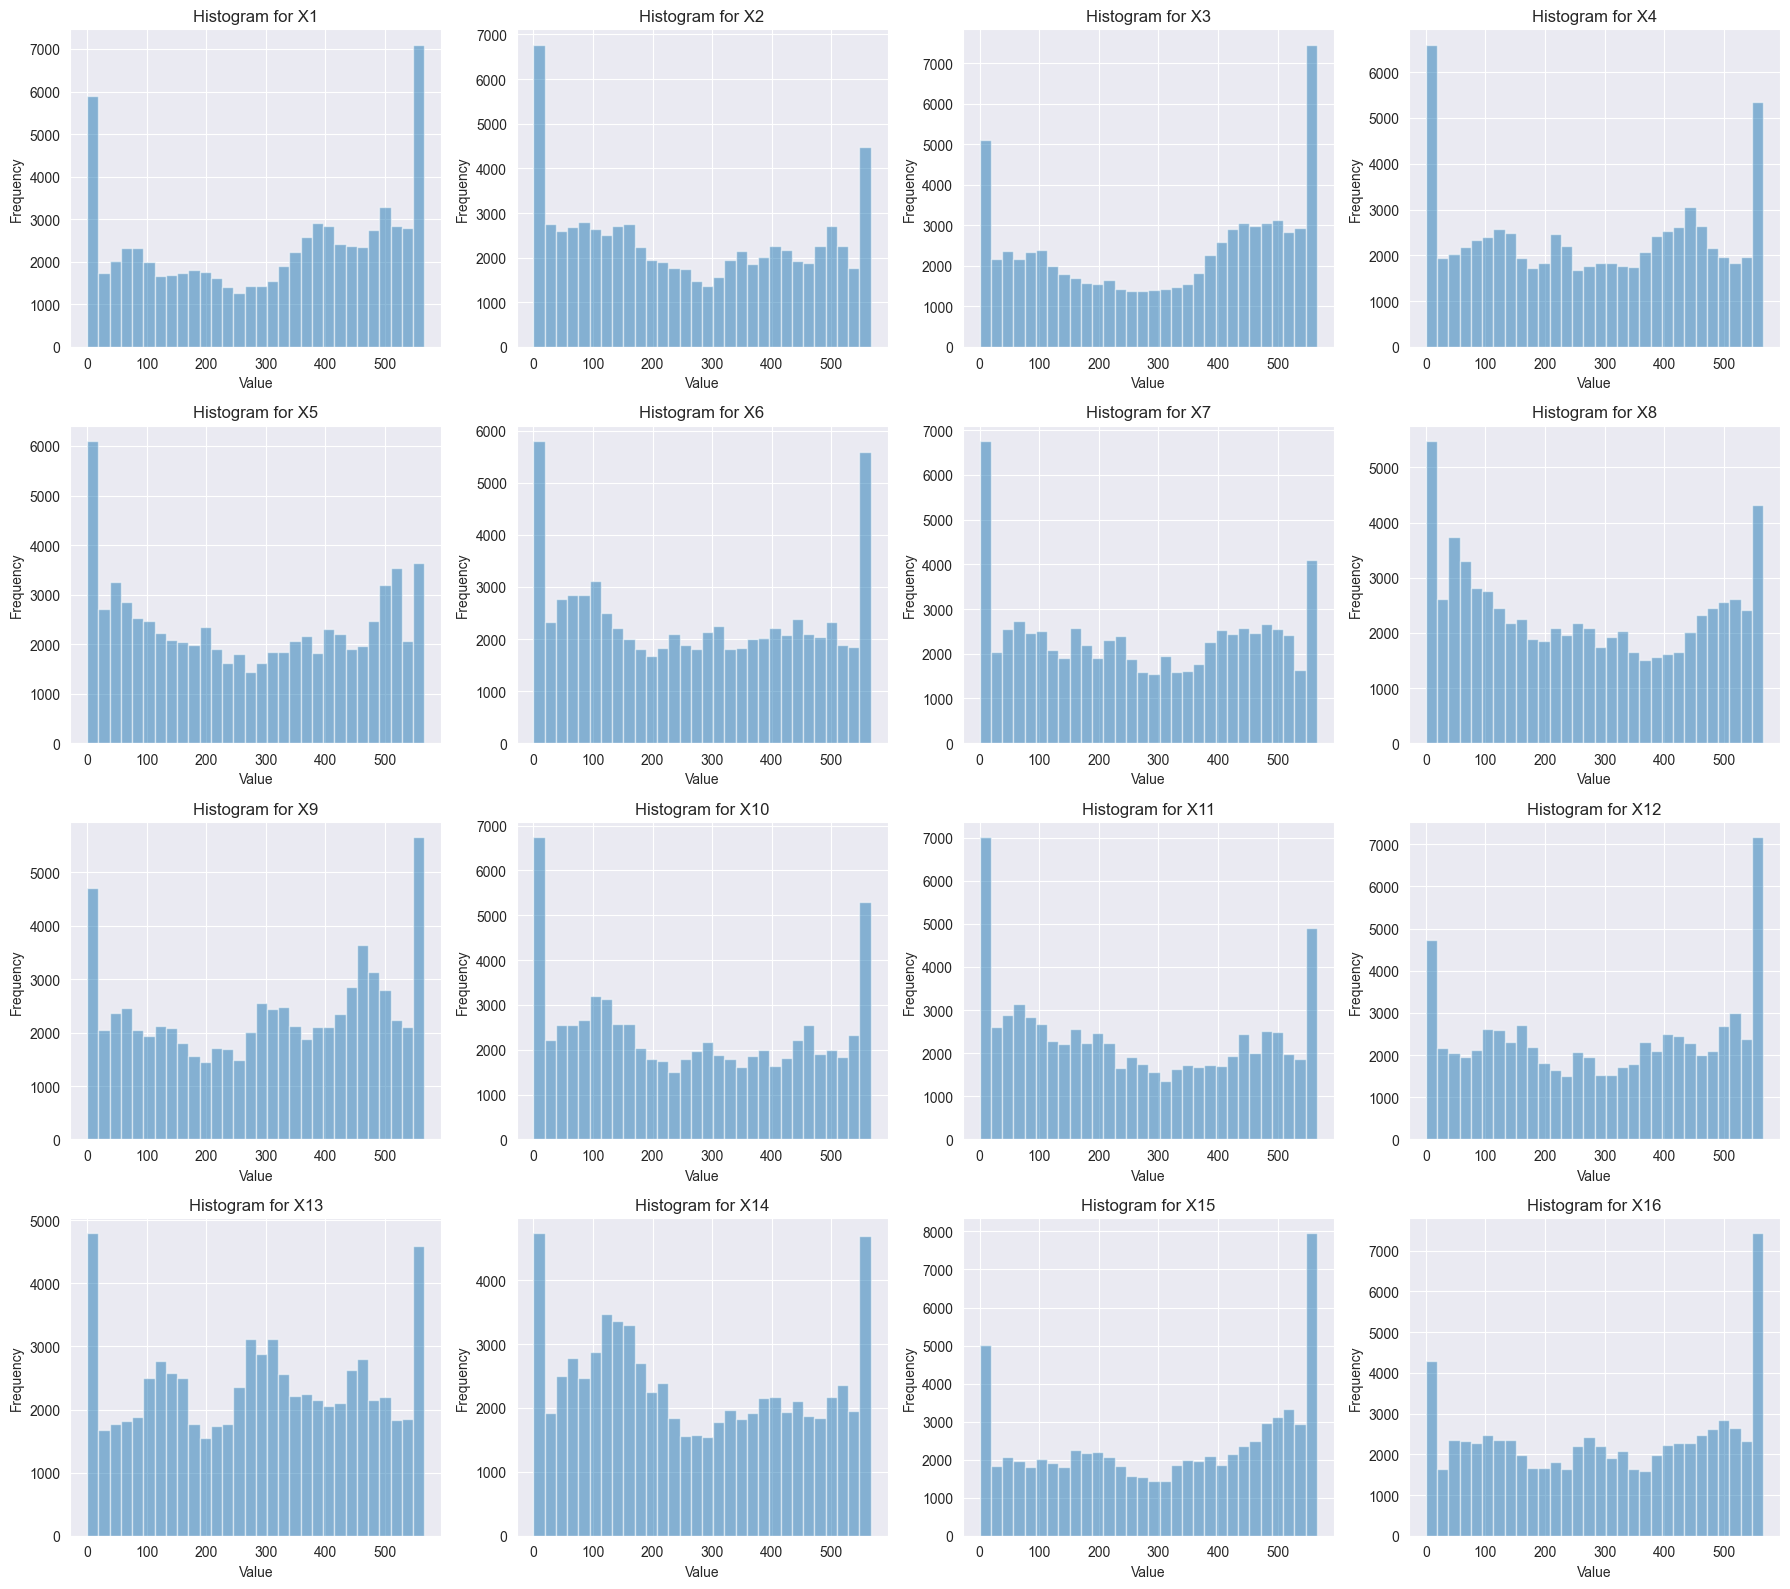

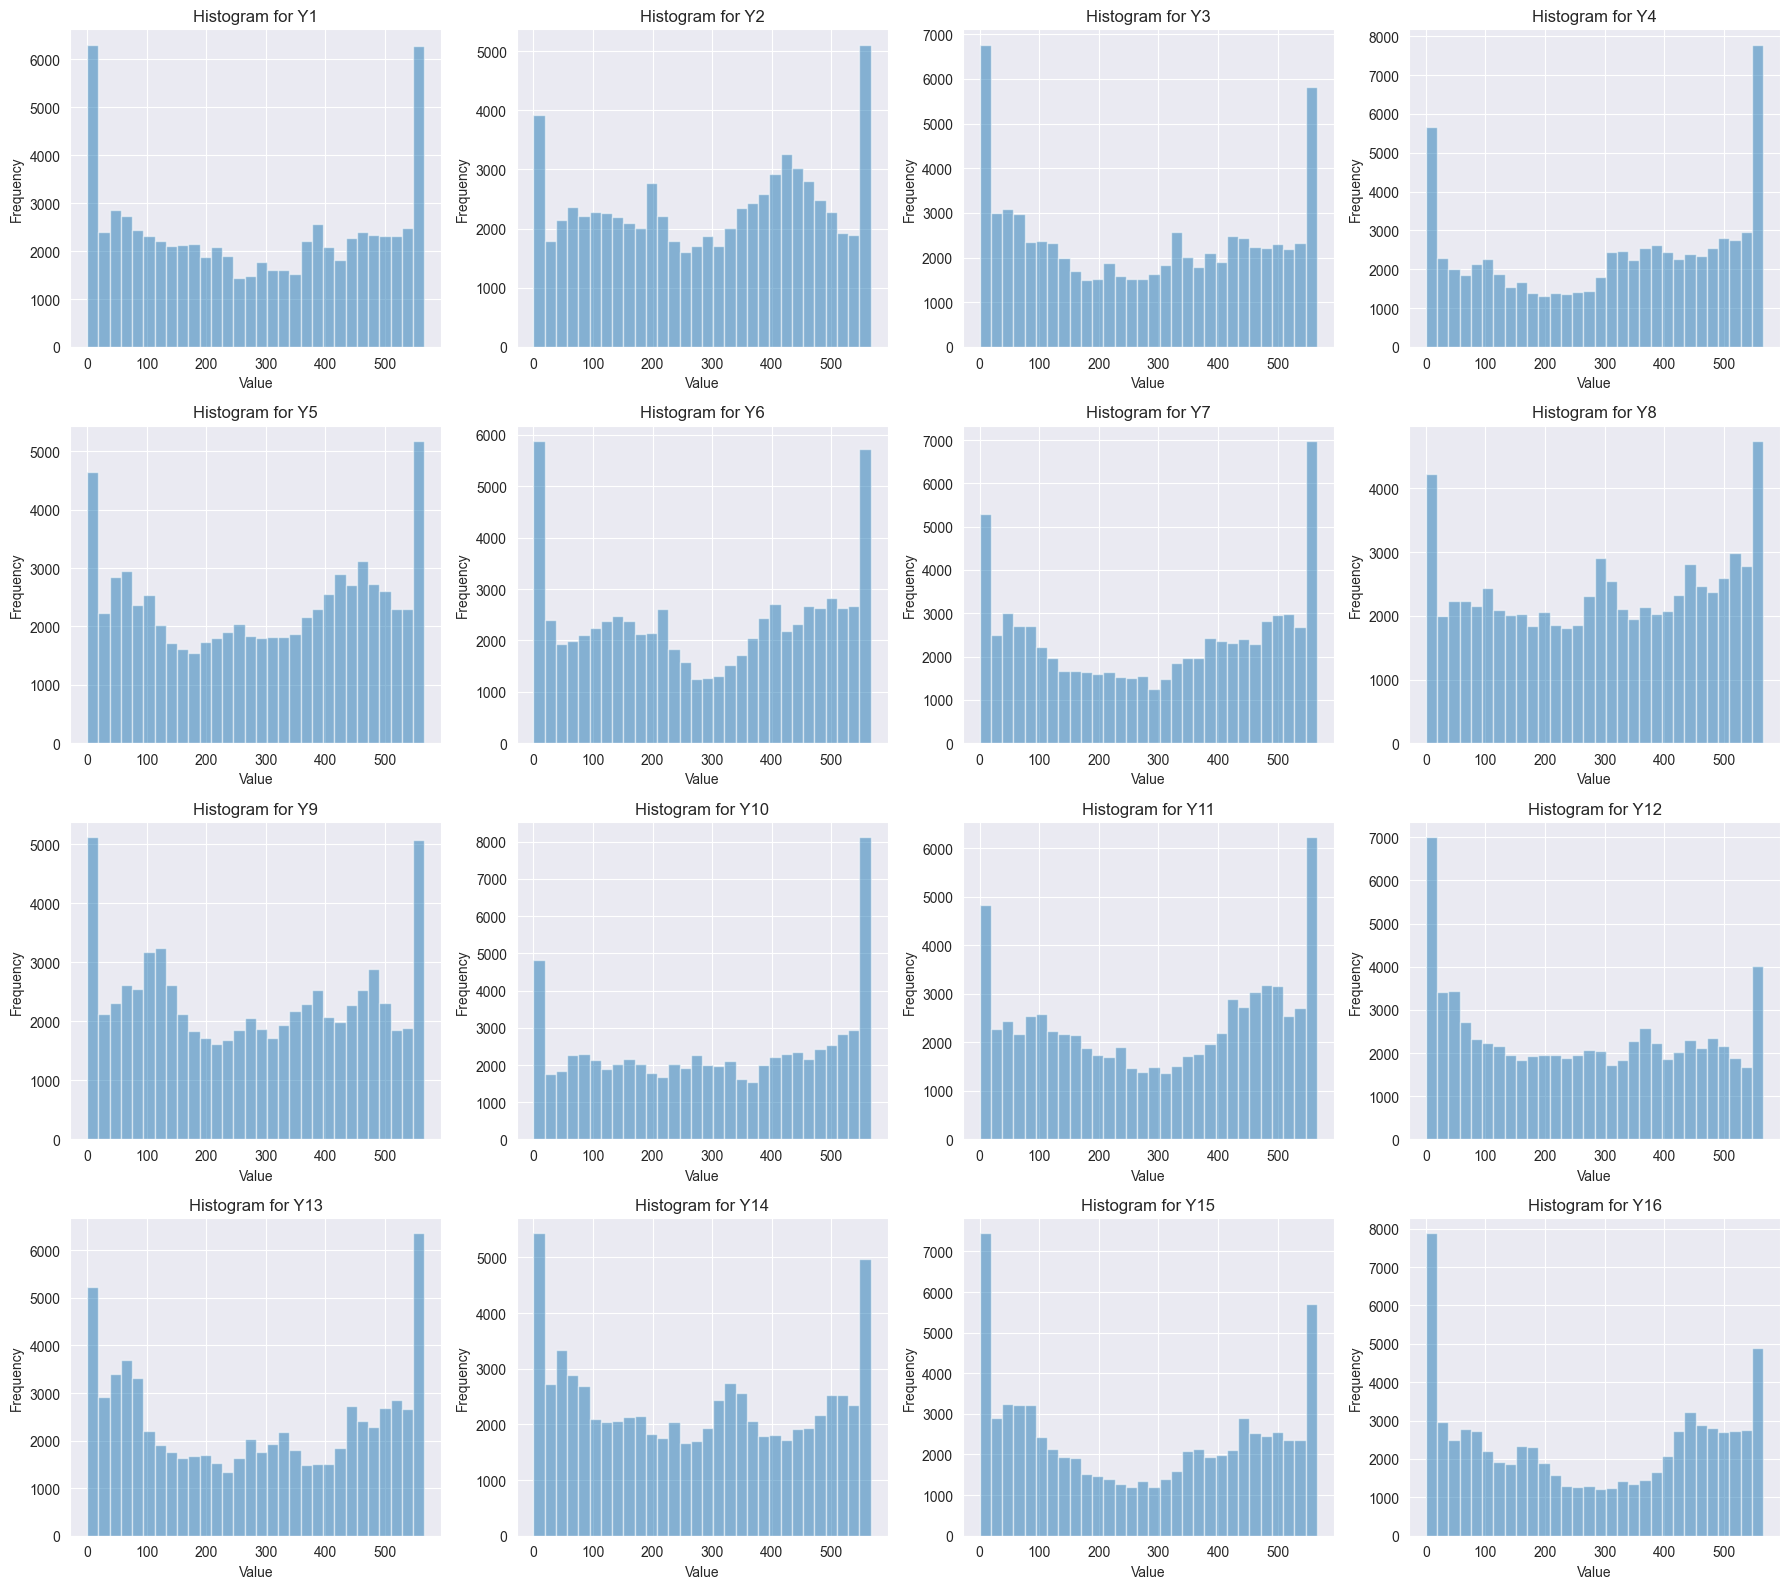

In [5]:
fig, axes = plt.subplots(4, 4, figsize=(18, 16))
for i, ax in enumerate(axes.flatten()):
    df[f"X{i+1}"].plot(kind='hist', bins=30, alpha=0.5, ax=ax)
    ax.set_title(f'Histogram for X{i+1}')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(4, 4, figsize=(18, 16))
for i, ax in enumerate(axes.flatten()):
    df[f"Y{i+1}"].plot(kind='hist', bins=30, alpha=0.5, ax=ax)
    ax.set_title(f'Histogram for Y{i+1}')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()


#### Both Feature Y and Feature X exhibit a significant number of outliers concentrated at the extremes of their respective ranges. This suggests that the area within which the converters were operating was constrained. Consequently, due to ocean currents, there were numerous instances where the converters were positioned at the boundaries of the interval.

#### The visualization above shows the frequency of measurements recorded by Converter 1 within the given space.

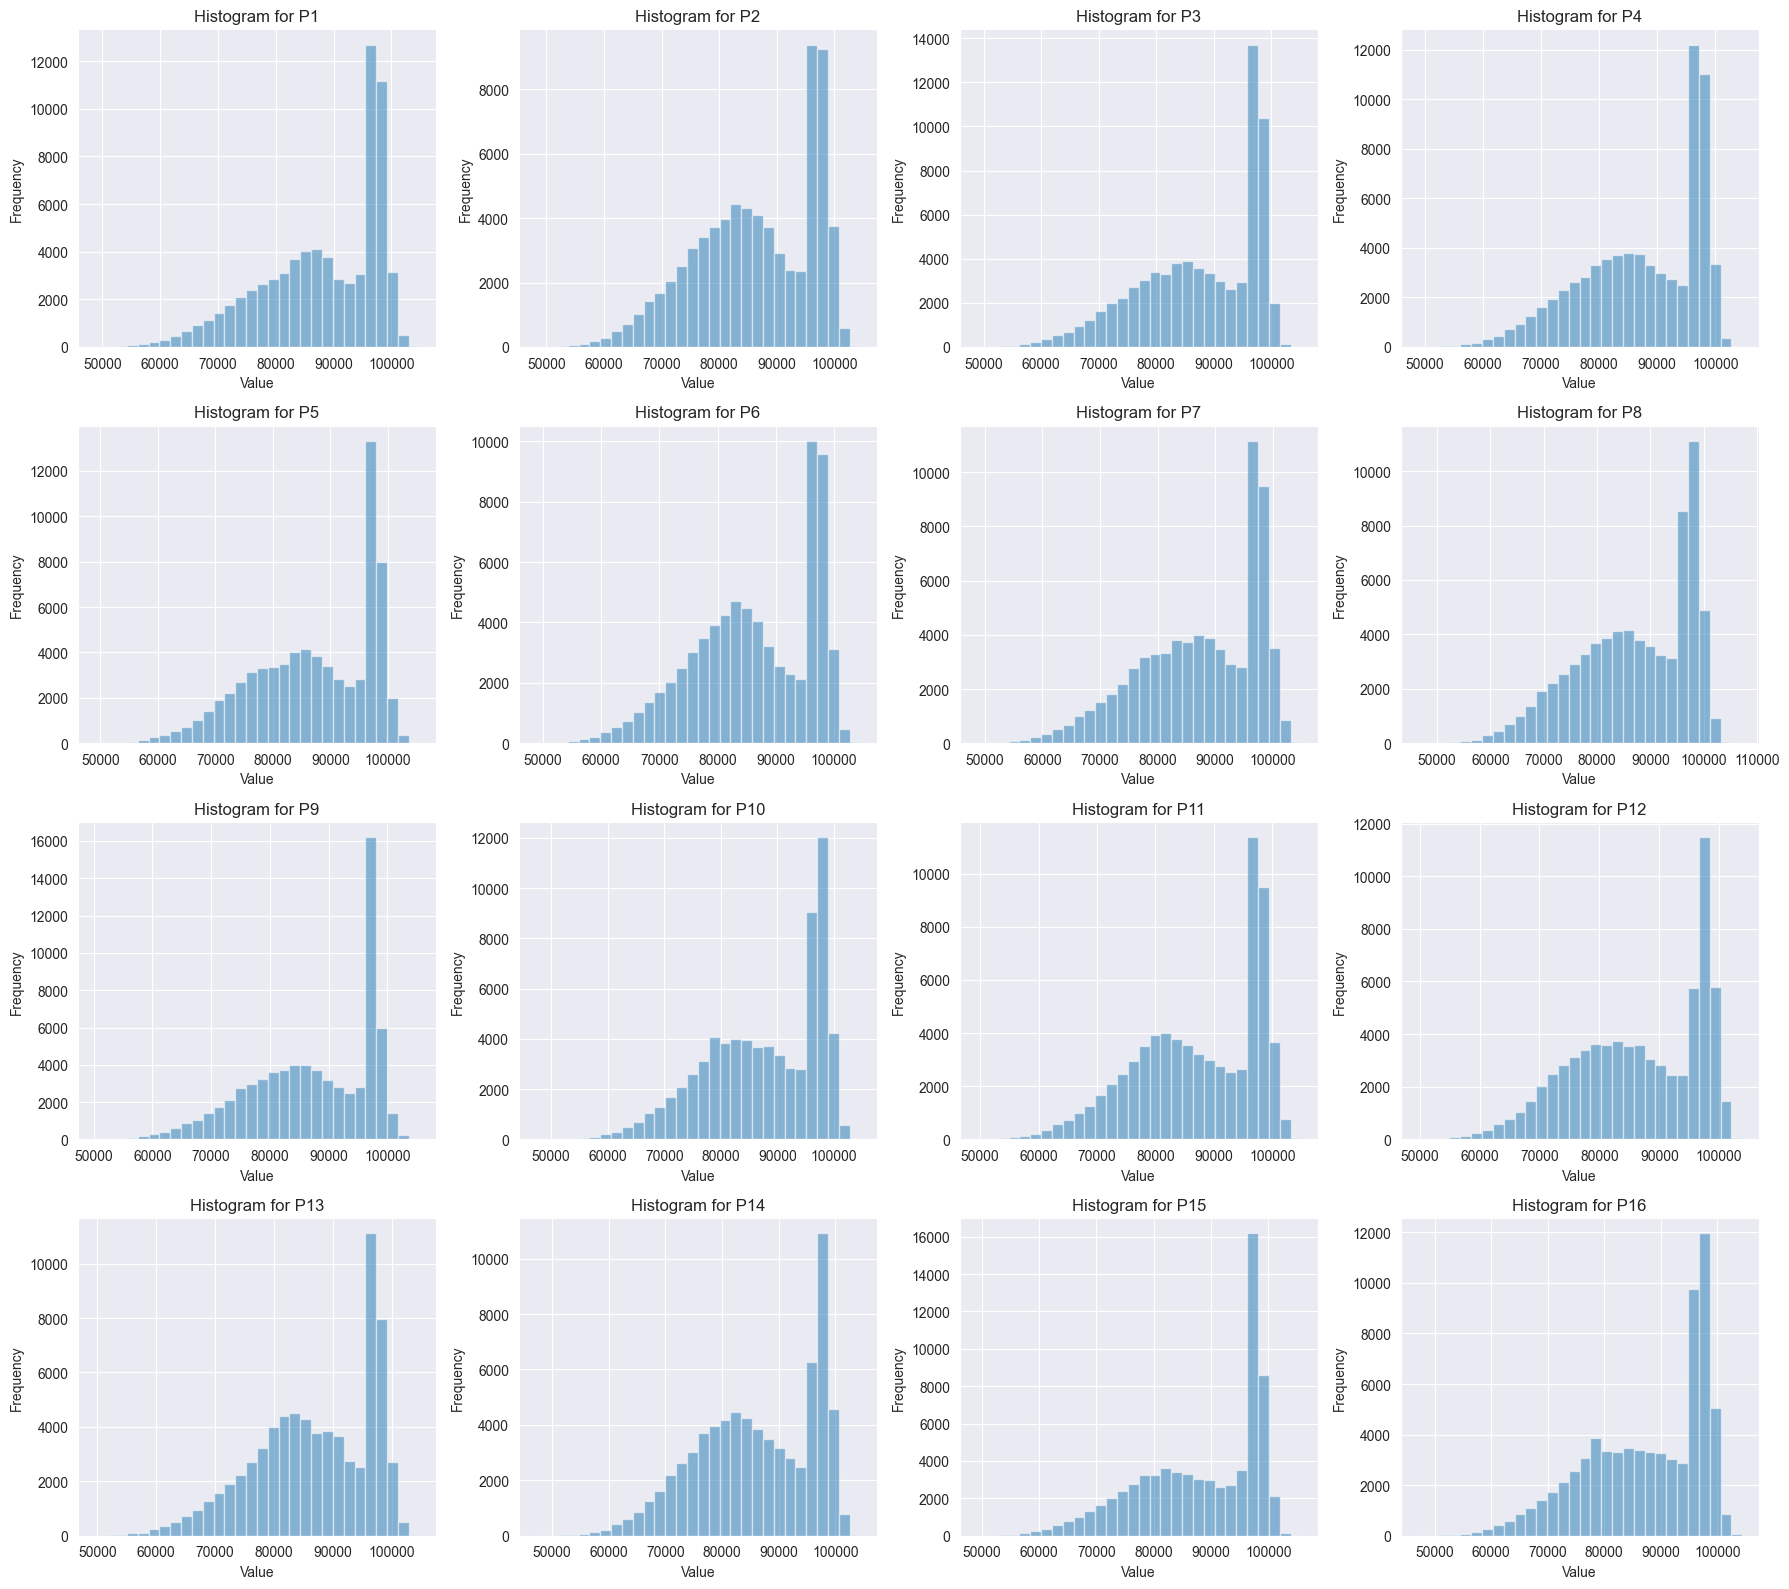

<Figure size 640x480 with 0 Axes>

In [6]:
fig, axes = plt.subplots(4, 4, figsize=(18, 16))
for i, ax in enumerate(axes.flatten()):
    df[f"P{i+1}"].plot(kind='hist', bins=30, alpha=0.5, ax=ax)
    ax.set_title(f'Histogram for P{i+1}')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()
plt.tight_layout()
plt.show()

<Axes: >

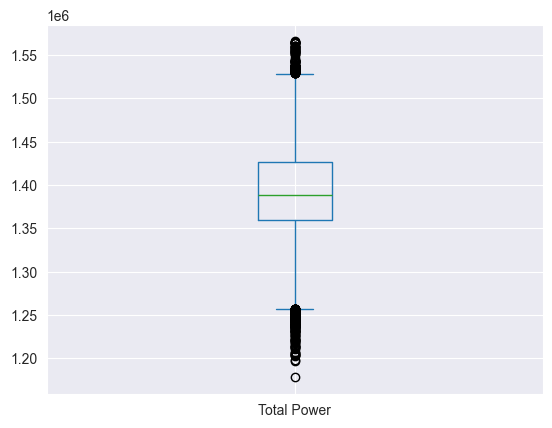

In [7]:
df["Total Power"].plot(kind='box')


<Axes: >

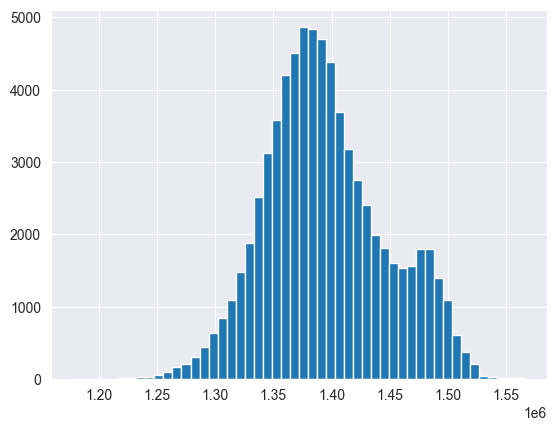

In [8]:
df["Total Power"].hist(bins=50)

#### The histograms of Energy values suggest the need to remove outliers.

In [9]:
# Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1 = df['Total Power'].quantile(0.25)
Q3 = df['Total Power'].quantile(0.75)
IQR = Q3 - Q1
# Define the lower and upper bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
# Filter out the outliers
df_filtered = df[(df['Total Power'] >= lower_bound) & (df['Total Power'] <= upper_bound)]
# Print the number of rows before and after filtering
print(f"Number of rows before filtering: {len(df)}")
print(f"Number of rows after filtering: {len(df_filtered)}")
df = df_filtered

Number of rows before filtering: 71999
Number of rows after filtering: 71710


<Axes: >

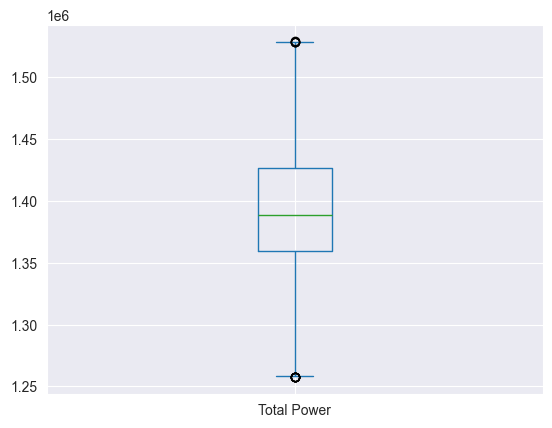

In [10]:
df["Total Power"].plot(kind='box')


<Axes: >

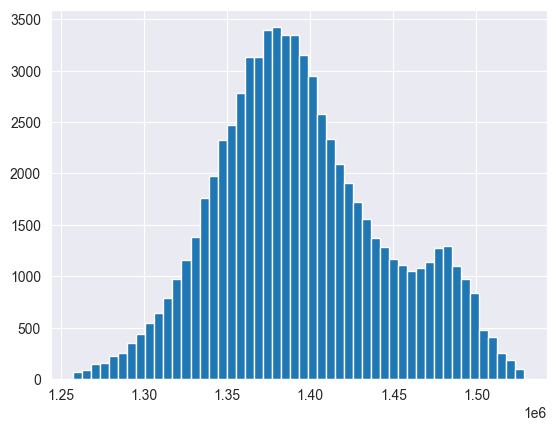

In [11]:
df["Total Power"].hist(bins=50)

#### The histograms of Energy values after remove outliers.

### Correration

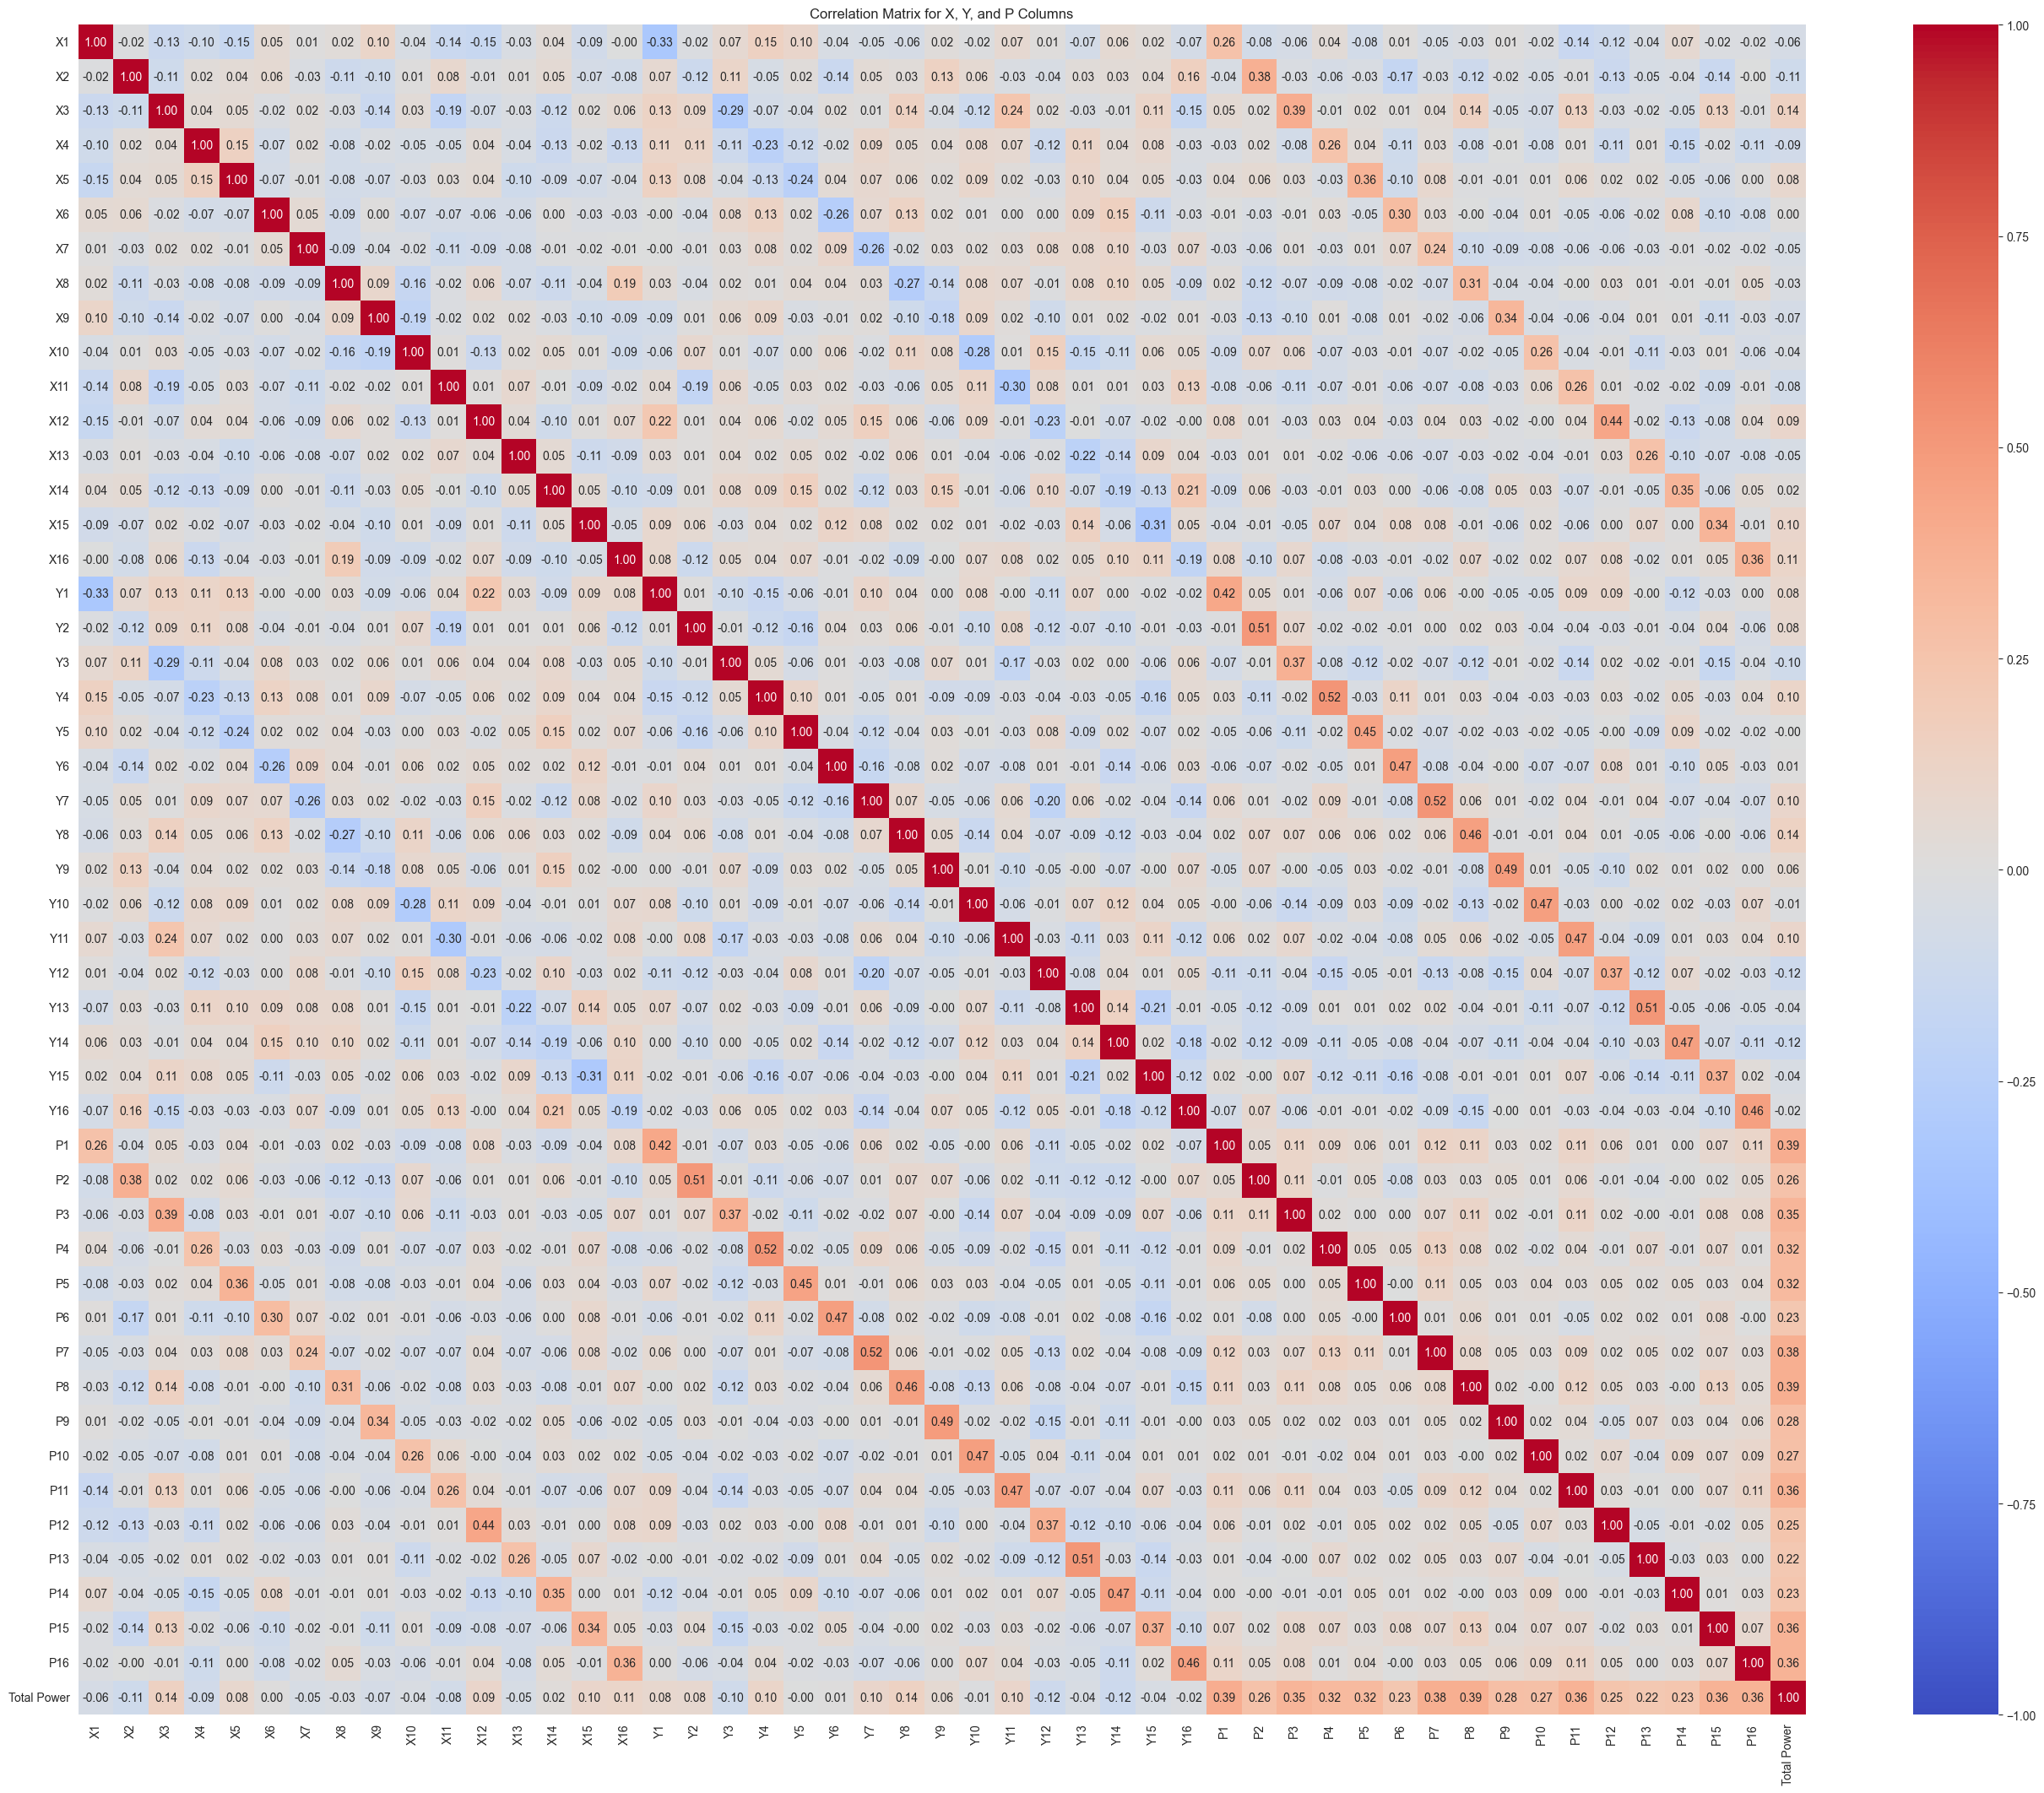

In [12]:
all_columns = labels
corr_all = df[all_columns].corr()

# Plot the correlation heatmap
plt.figure(figsize=(33, 26))
sns.heatmap(corr_all, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix for X, Y, and P Columns')
plt.show()

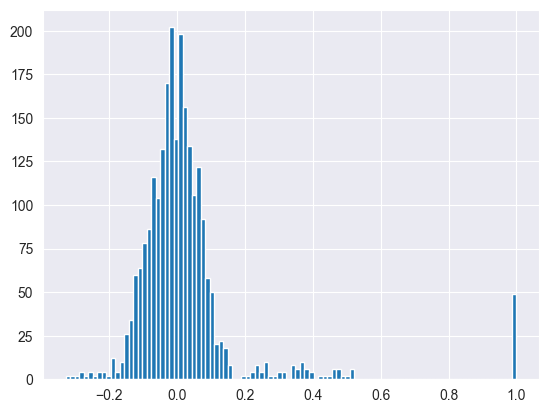

In [13]:
tab = corr_all.to_numpy().reshape(-1)
plt.hist(tab, bins = 100)
plt.show()

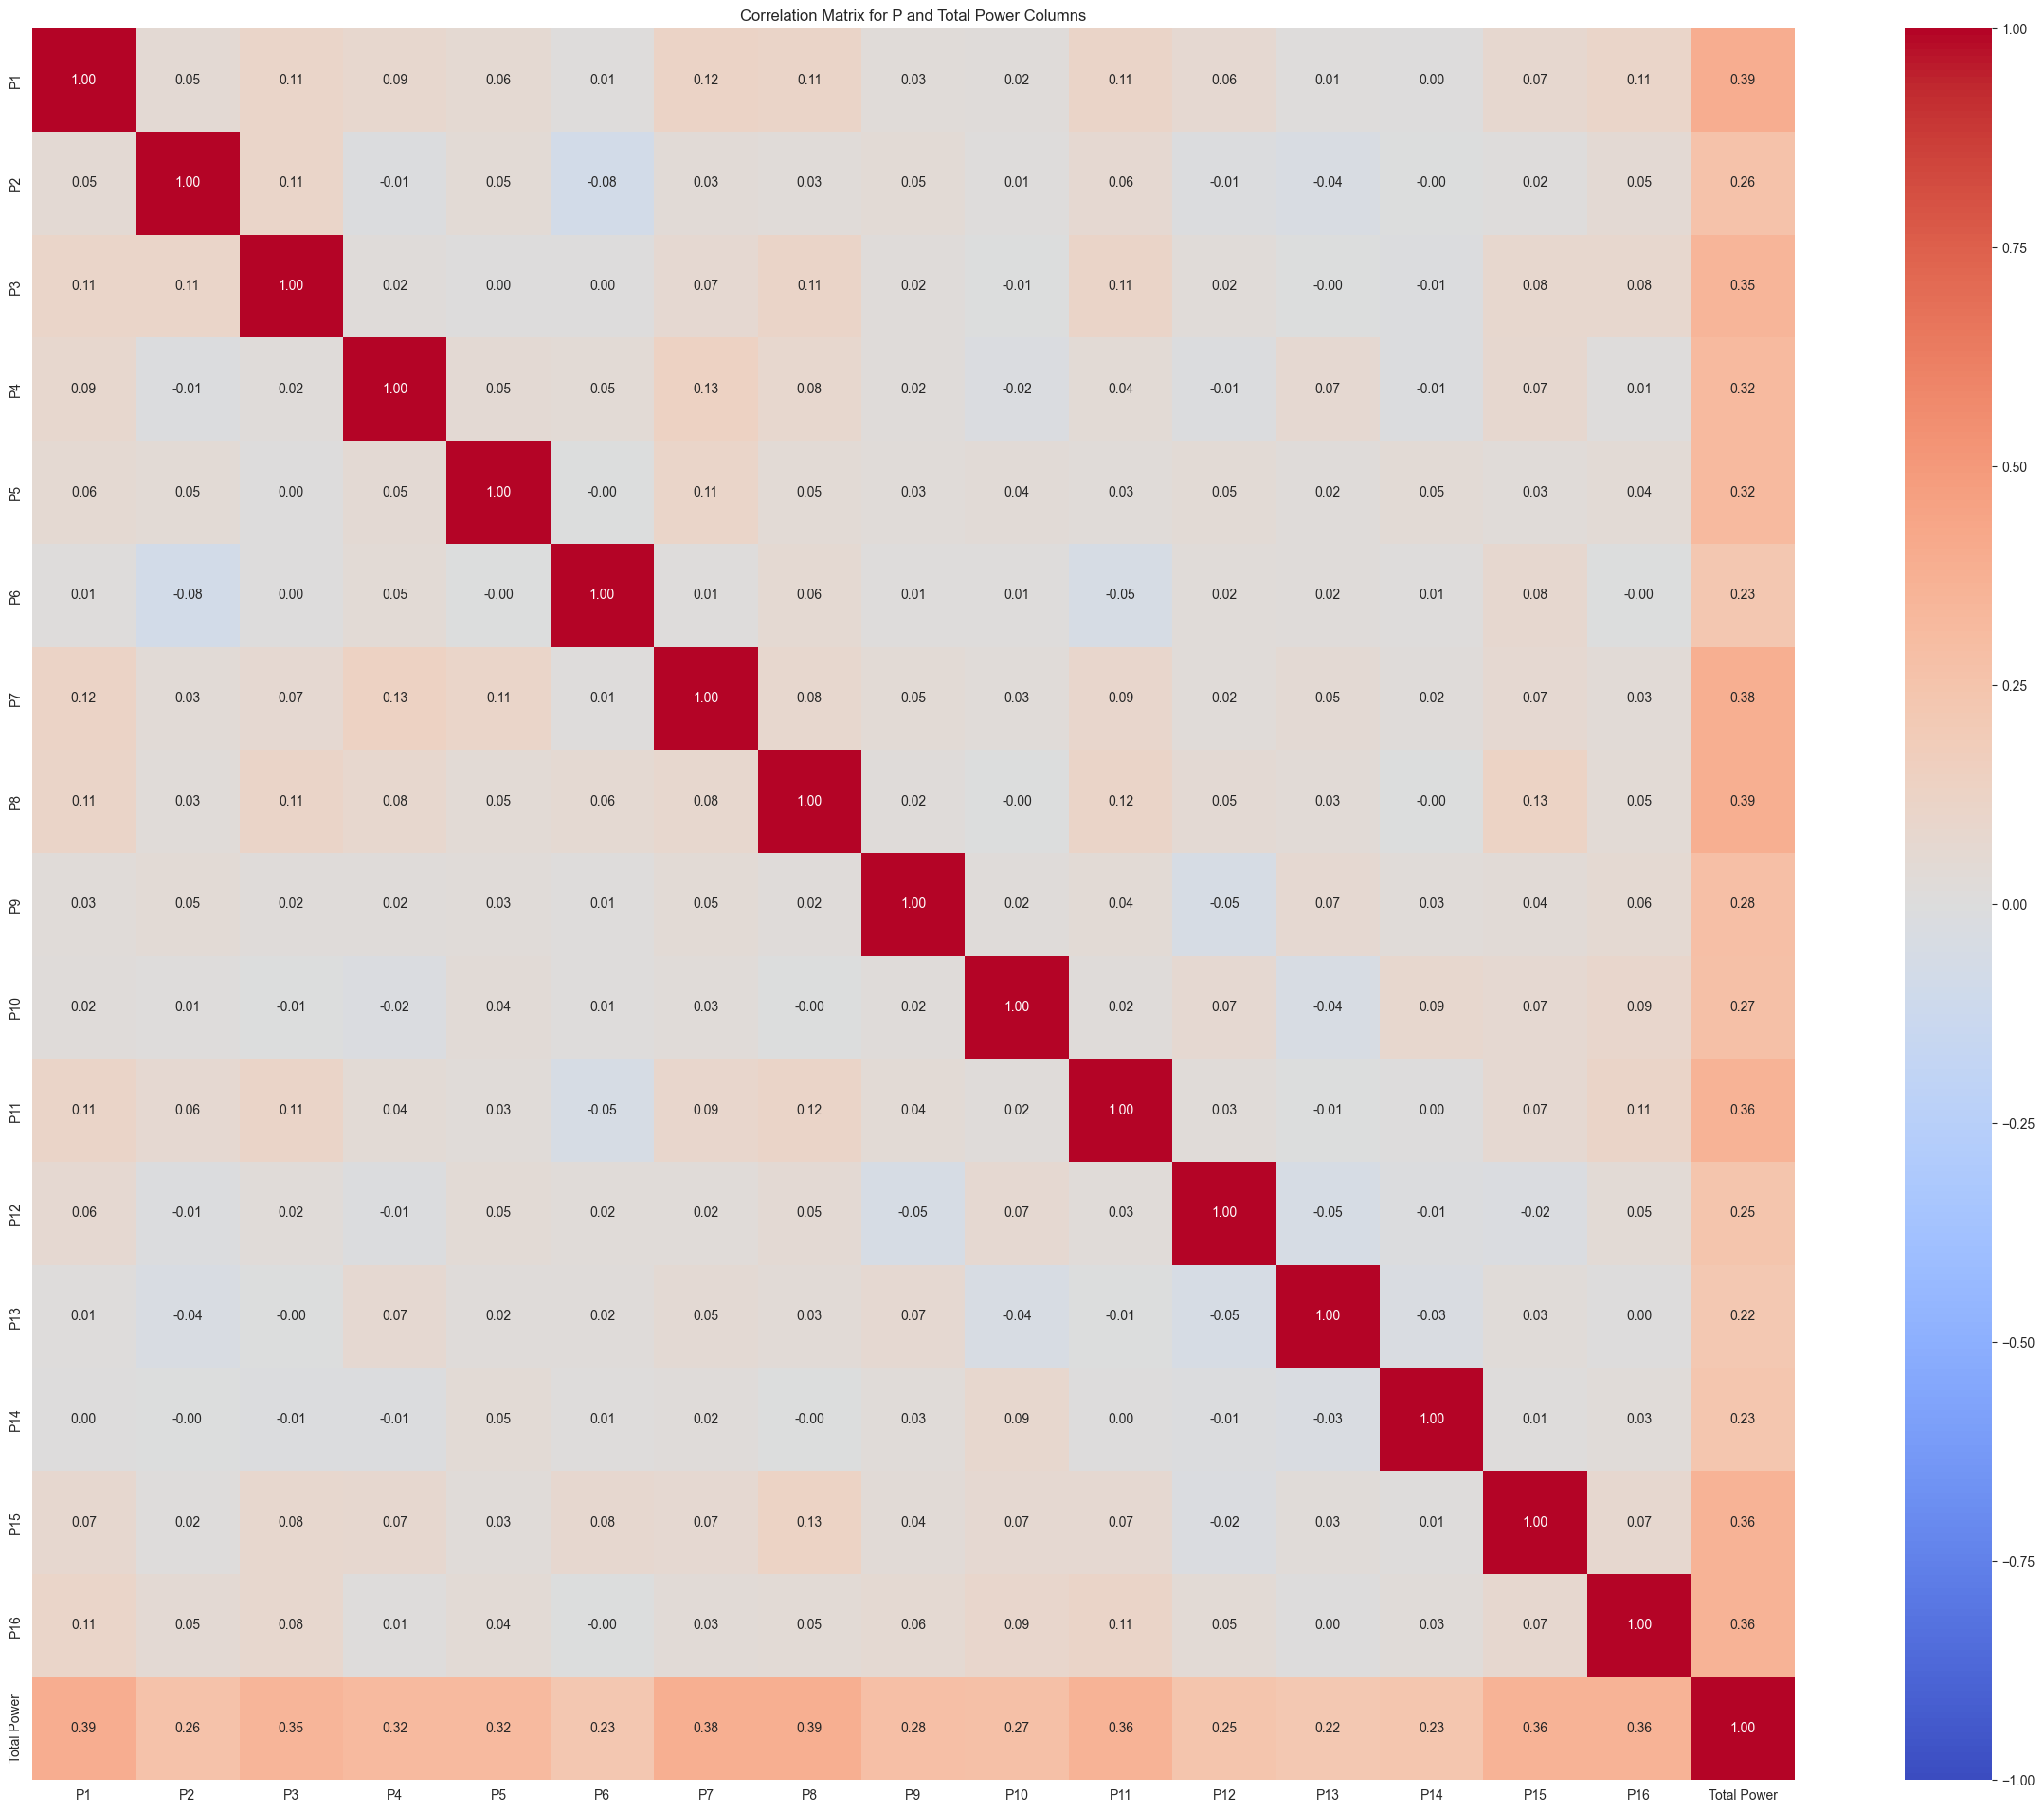

In [14]:
power_columns = [f"P{i+1}" for i in range(16)] + ["Total Power"]
corr = df[power_columns].corr()
plt.figure(figsize=(30, 24))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix for P and Total Power Columns')
plt.show()

#### correlation is observed between P1-P16 and Total Power, based on the correlation histogram. Correlations above 0.2 can be considered significant. For this reason, the P1-P16 values are not needed, as we want to avoid training our model on output data. This analysis confirms that P1-P16 are indeed output data.

In [15]:
new_labels = labels = [f"X{i+1}" for i in range(16)] + [f"Y{i+1}" for i in range(16)] + ["Total Power"]
df = df[new_labels]
df.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,Y8,Y9,Y10,Y11,Y12,Y13,Y14,Y15,Y16,Total Power
0,427.4820,147.4593,474.9960,9.5407,258.2593,404.2589,524.3422,44.4009,70.4385,468.8828,...,519.1315,364.8982,65.3082,101.1422,490.5889,345.8587,239.1995,12.1615,68.4592,1479133.940
1,423.7709,155.9451,470.8182,4.0438,253.8868,390.2231,509.0224,50.7996,72.8076,463.4203,...,525.0178,371.9532,81.5468,95.3886,475.8627,350.7924,240.0667,7.0359,86.0173,1475814.243
2,431.8288,146.6720,466.1145,7.0164,261.3787,408.9941,521.9852,44.0360,77.5854,450.5736,...,513.8518,371.2593,77.4516,92.7453,478.5863,348.8754,227.3840,1.0817,78.1879,1484052.684
3,437.7897,141.3579,474.3819,4.3434,256.5644,393.0113,516.1617,52.4880,66.1179,457.0365,...,503.1606,372.2845,82.0181,87.2123,482.1999,346.8257,226.7739,0.0000,83.0666,1479350.362
4,450.8980,144.7559,475.3267,2.5512,241.1346,400.2228,510.2312,54.6467,78.7078,466.5793,...,517.8953,373.6055,68.8797,101.4923,482.3627,334.8205,218.6794,0.0000,79.9809,1480235.758


#### Create Train , Test and Validation set

In [16]:
df_s = df.sample(n=71000,random_state=44)
#features
X = df_s.iloc[:,1:-1].values
#targets
y = df_s['Total Power'].values
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=44)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=44)

#### Features normalization

In [17]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

#### Linear Regrasion

In [18]:
model_linear = LinearRegression()
model_linear.fit(X_train, y_train)
y_val_pred = model_linear.predict(X_val)
rmse = root_mean_squared_error(y_val, y_val_pred)
mse = mean_squared_error(y_test, y_val_pred)
print(f"Linear Regression: RMSE = {rmse}")
print(f"Linear Regression: MSE = {mse}")

Linear Regression: RMSE = 47745.27607359156
Linear Regression: MSE = 3010992309.404578


#### Random Forest

In [19]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error
import numpy as np
import xgboost as xgb
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import  r2_score


# 1. Definicja modelu XGBoost i siatki hiperparametrów
models = {
    "LinearRegression": LinearRegression(),
    # "RandomForest": RandomForestRegressor(random_state=42),
    "GradientBoosting": GradientBoostingRegressor(random_state=42),
    "kNN": KNeighborsRegressor(),
    "XGBoost": xgb.XGBRegressor(random_state=42)
}

param_grids = {
    "LinearRegression": {},  # Brak hiperparametrów
    # "RandomForest": {
    #     "n_estimators": [50, 100, 200],
    #     "max_depth": [None, 10, 20],
    #     "min_samples_split": [2, 5],
    # },
    "GradientBoosting": {
        "n_estimators": [50, 100, 200],
        "learning_rate": [0.01, 0.1, 0.2],
        "max_depth": [3, 5, 10],
    },
    "kNN": {
        "n_neighbors": [3, 5, 7, 10],
        "weights": ["uniform", "distance"],
        "p": [1, 2],
    }
    ,
    "XGBoost": {
        "n_estimators": [50, 100, 200],
        "learning_rate": [0.05, 0.1, 0.2],
        "max_depth": [3, 5, 10],
    }
}

# 2. Trening i strojenie XGBoost
best_models = {}
for name, model in models.items():
    print(f"Training {name}...")
    grid = GridSearchCV(
        estimator=model,
        param_grid=param_grids[name],
        cv=3,  # Cross-validation folds
        scoring="neg_mean_squared_error",
        n_jobs=-1,
    )
    grid.fit(X_train, y_train)
    best_models[name] = grid.best_estimator_

    # Walidacja
    y_val_pred = grid.best_estimator_.predict(X_val)
    rmse_val = np.sqrt(mean_squared_error(y_val, y_val_pred))
    print(f"{name} - Best RMSE on validation set: {rmse_val:.4f}")

# 3. Ewaluacja na zbiorze testowym
print("\nEvaluating on test set...")
best_model = min(
    best_models.items(),
    key=lambda x: np.sqrt(mean_squared_error(y_val, x[1].predict(X_val)))
)[1]
y_test_pred = best_model.predict(X_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2 = r2_score(y_test, y_test_pred)
print(f"Best Model: {best_model.__class__.__name__}")
print(f"RMSE on test set: {rmse_test:.4f}")
print("R²", r2)

Training LinearRegression...
LinearRegression - Best RMSE on validation set: 47745.2761
Training GradientBoosting...
GradientBoosting - Best RMSE on validation set: 20125.2351
Training kNN...
kNN - Best RMSE on validation set: 23726.3113
Training XGBoost...
XGBoost - Best RMSE on validation set: 20218.1594

Evaluating on test set...
Best Model: GradientBoostingRegressor
RMSE on test set: 20053.6101
R² 0.8489107490603724
